# Benchmark RPM / TPM — mesure des limites réelles

**Ce notebook fait de vraies requêtes API payantes.**

### Protocole

| Test | Stratégie | Ce qu'on observe |
|------|-----------|------------------|
| **RPM** | Rafale de `N_BURST` requêtes concurrentes (prompt minimal) | Nombre de succès + message 429-RPM avec `Limit X` |
| **TPM** | 1 requête avec un prompt de `~PROMPT_TOKENS` tokens | 413/429-TPM avec `Limit X, Requested Y` |

Les messages d'erreur Groq contiennent le quota exact ; Mistral/Cerebras/Google
ne donnent pas de détail numérique — on note simplement si la requête passe ou non.

In [28]:
# Parameters
CONFIG_PATH   = '../../llm_module/config/providers.yaml'
ENV_PATH      = '../../.env'
N_BURST       = 500    # requêtes concurrentes pour le test RPM
PROMPT_TOKENS = 7000   # taille cible du prompt long pour le test TPM
SKIP          = []     # ex: ['openai'] pour exclure un provider

In [29]:
import asyncio, json, os, re, time
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import yaml

# ── .env ───────────────────────────────────────────────────────────────────────
for line in Path(ENV_PATH).read_text().splitlines():
    line = line.strip()
    if line and not line.startswith('#') and '=' in line:
        k, _, v = line.partition('=')
        if k.strip() not in os.environ:
            os.environ[k.strip()] = v.strip()

# ── providers.yaml ─────────────────────────────────────────────────────────────
with open(CONFIG_PATH) as f:
    providers_raw = yaml.safe_load(f)['providers']

providers = {}
for name, cfg in providers_raw.items():
    if name in SKIP:
        continue
    adapter = cfg.get('adapter', name)
    key = os.environ.get(f'PROVIDER_KEYS__{adapter}', '') or os.environ.get(f'PROVIDER_KEYS__{name}', '')
    providers[name] = {**cfg, 'api_key': key, 'adapter_type': adapter}

# ── Affichage ─────────────────────────────────────────────────────────────────
rows = []
for n, c in providers.items():
    rows.append({'provider': n, 'model': c['default_model'],
                 'rpm_config': c.get('rpm_limit'), 'tpm_config': c.get('tpm_limit'),
                 'tpd_config': c.get('tpd_limit'), 'clé': '✓' if c['api_key'] else '✗'})
display(pd.DataFrame(rows).set_index('provider'))

,model,rpm_config,tpm_config,tpd_config,clé
provider,,,,,
openai,gpt-4o-mini,15,200000.0,2000000.0,✗
mistral,mistral-small-latest,90,500000.0,2000000.0,✓
google_gemini31,gemini-3.1-flash-lite-preview,15,250000.0,NaN,✓
google_gemma42,gemma-4-26b-a4b-it,15,NaN,NaN,✓
google_gemma43,gemma-4-31b-it,15,NaN,NaN,✓
groq_llama3,llama-3.3-70b-versatile,30,12000.0,100000.0,✓
groq_llama4,meta-llama/llama-4-scout-17b-16e-instruct,30,30000.0,500000.0,✓
groq_qwen,qwen/qwen3-32b,60,6000.0,500000.0,✓
groq_llama31,llama-3.1-8b-instant,30,6000.0,500000.0,✓


## Helpers

In [30]:
# ── Regex pour extraire les limites des messages d'erreur ──────────────────────
_RPM_RE = re.compile(
    r'on requests per minute \(RPM\): Limit ([\d,]+),\s*Used ([\d,]+)',
    re.IGNORECASE,
)
_TPM_RE = re.compile(
    r'on tokens per (?:minute|day) \((\w+)\): Limit (\d[\d,]*\d|\d+)'
    r'(?:,\s*Used (\d[\d,]*\d|\d+))?'
    r'(?:,\s*Requested (\d[\d,]*\d|\d+))?',
    re.IGNORECASE,
)

def _parse_rpm_limit(text: str):
    m = _RPM_RE.search(text)
    return int(m.group(1).replace(',', '')) if m else None

def _parse_tpm_info(text: str):
    m = _TPM_RE.search(text)
    if not m:
        return None
    return {
        'quota_type': m.group(1),
        'limit':      int(m.group(2).replace(',', '')),
        'used':       int(m.group(3).replace(',', '')) if m.group(3) else None,
        'requested':  int(m.group(4).replace(',', '')) if m.group(4) else None,
    }


# ── Fonctions d'appel HTTP ─────────────────────────────────────────────────────
async def _call_openai_compat(cfg: dict, prompt: str, client: httpx.AsyncClient) -> dict:
    t0 = time.monotonic()
    try:
        r = await client.post(
            f"{cfg['base_url']}/chat/completions",
            headers={'Authorization': f"Bearer {cfg['api_key']}", 'Content-Type': 'application/json'},
            json={'model': cfg['default_model'],
                  'messages': [{'role': 'user', 'content': prompt}],
                  'max_tokens': 10},
            timeout=60.0,
        )
        ms = round((time.monotonic() - t0) * 1000, 1)
        if r.status_code == 200:
            usage = r.json().get('usage', {})
            return {'ok': True, 'status': 200, 'ms': ms,
                    'tokens_in': usage.get('prompt_tokens', 0),
                    'tokens_out': usage.get('completion_tokens', 0),
                    'body': None}
        return {'ok': False, 'status': r.status_code, 'ms': ms,
                'tokens_in': 0, 'tokens_out': 0, 'body': r.text}
    except Exception as exc:
        return {'ok': False, 'status': None, 'ms': round((time.monotonic()-t0)*1000, 1),
                'tokens_in': 0, 'tokens_out': 0, 'body': str(exc)}


async def _call_google(cfg: dict, prompt: str, client: httpx.AsyncClient) -> dict:
    url = f"{cfg['base_url']}/models/{cfg['default_model']}:generateContent?key={cfg['api_key']}"
    t0 = time.monotonic()
    try:
        r = await client.post(
            url,
            json={'contents': [{'role': 'user', 'parts': [{'text': prompt}]}],
                  'generationConfig': {'maxOutputTokens': 10}},
            headers={'Content-Type': 'application/json'},
            timeout=60.0,
        )
        ms = round((time.monotonic() - t0) * 1000, 1)
        if r.status_code == 200:
            usage = r.json().get('usageMetadata', {})
            return {'ok': True, 'status': 200, 'ms': ms,
                    'tokens_in': usage.get('promptTokenCount', 0),
                    'tokens_out': usage.get('candidatesTokenCount', 0),
                    'body': None}
        return {'ok': False, 'status': r.status_code, 'ms': ms,
                'tokens_in': 0, 'tokens_out': 0, 'body': r.text}
    except Exception as exc:
        return {'ok': False, 'status': None, 'ms': round((time.monotonic()-t0)*1000, 1),
                'tokens_in': 0, 'tokens_out': 0, 'body': str(exc)}


async def call(name: str, cfg: dict, prompt: str, client: httpx.AsyncClient) -> dict:
    if cfg['adapter_type'] == 'google':
        return await _call_google(cfg, prompt, client)
    return await _call_openai_compat(cfg, prompt, client)


# ── Prompts TPM par provider : tpm_config × 1.1, plafonné à MAX_PROMPT_TOKENS ─
# Objectif : dépasser la limite configurée pour chaque provider.
# On plafonne pour éviter un coût excessif sur les providers à haute limite.
MAX_PROMPT_TOKENS = 35_000   # ~140 000 chars, raisonnable en coût

_BASE = (
    "Urban mobility planning requires careful analysis of transportation networks. "
    "Each commuter has unique preferences, constraints, and sensitivities to cost, time, comfort, "
    "and environmental impact. The optimal mode depends on distance, weather, physical ability, "
    "car availability, transit schedules, and individual priorities. "
)
_TOKENS_PER_REP = 70   # ~70 tokens par répétition de _BASE

def _make_prompt(n_tokens: int) -> str:
    return _BASE * max(1, n_tokens // _TOKENS_PER_REP)

SHORT_PROMPT = 'Say ok'

# Table des prompts par provider
provider_prompts = {}
print(f"{'Provider':<25} {'tpm_config':>12}  {'prompt_tokens':>14}  {'statut'}")
print("-" * 70)
for name, cfg in providers.items():
    if not cfg['api_key']:
        continue
    tpm_cfg = cfg.get('tpm_limit')
    if tpm_cfg:
        target = min(int(tpm_cfg * 1.1) + 500, MAX_PROMPT_TOKENS)
        note   = 'cap' if target == MAX_PROMPT_TOKENS else 'tpm × 1.1'
    else:
        target = PROMPT_TOKENS
        note   = 'défaut (tpm_limit null)'
    provider_prompts[name] = _make_prompt(target)
    actual_chars = len(provider_prompts[name])
    print(f"{name:<25} {str(tpm_cfg):>12}  {target:>14,}  {note}  (~{actual_chars//4} tokens estimés)")


Provider                    tpm_config   prompt_tokens  statut
----------------------------------------------------------------------
mistral                         500000          35,000  cap  (~40750 tokens estimés)
google_gemini31                 250000          35,000  cap  (~40750 tokens estimés)
google_gemma42                    None           7,000  défaut (tpm_limit null)  (~8150 tokens estimés)
google_gemma43                    None           7,000  défaut (tpm_limit null)  (~8150 tokens estimés)
groq_llama3                      12000          13,700  tpm × 1.1  (~15892 tokens estimés)
groq_llama4                      30000          33,500  tpm × 1.1  (~38957 tokens estimés)
groq_qwen                         6000           7,100  tpm × 1.1  (~8231 tokens estimés)
groq_llama31                      6000           7,100  tpm × 1.1  (~8231 tokens estimés)
groq_openai_120                   8000           9,300  tpm × 1.1  (~10758 tokens estimés)
groq_openai_20                    8

## Test RPM — rafale de N_BURST requêtes concurrentes

In [31]:
rpm_results = {}

for name, cfg in providers.items():
    if not cfg['api_key']:
        print(f'{name}: pas de clé, ignoré.')
        continue
    print(f'→ {name} ({N_BURST} concurrent)...', end=' ', flush=True)
    t0 = time.monotonic()
    async with httpx.AsyncClient() as client:
        tasks = [call(name, cfg, SHORT_PROMPT, client) for _ in range(N_BURST)]
        results = await asyncio.gather(*tasks)
    elapsed = time.monotonic() - t0
    rpm_results[name] = {'results': results, 'elapsed_s': round(elapsed, 2)}

    ok    = sum(1 for r in results if r['ok'])
    e429  = sum(1 for r in results if r['status'] == 429)
    other = sum(1 for r in results if not r['ok'] and r['status'] != 429)
    first_err_body = next((r['body'] for r in results if not r['ok'] and r['body']), '')
    rpm_actual = _parse_rpm_limit(first_err_body or '')
    print(f'✓{ok}  429={e429}  autre={other}  {elapsed:.2f}s'
          + (f'  → RPM réel = {rpm_actual}' if rpm_actual else ''))

openai: pas de clé, ignoré.
→ mistral (500 concurrent)... ✓50  429=450  autre=0  5.44s
→ google_gemini31 (500 concurrent)... ✓17  429=483  autre=0  13.20s
→ google_gemma42 (500 concurrent)... ✓17  429=483  autre=0  5.37s
→ google_gemma43 (500 concurrent)... ✓17  429=483  autre=0  5.41s
→ groq_llama3 (500 concurrent)... ✓32  429=468  autre=0  5.26s  → RPM réel = 30
→ groq_llama4 (500 concurrent)... ✓50  429=450  autre=0  5.31s  → RPM réel = 30
→ groq_qwen (500 concurrent)... ✓75  429=425  autre=0  5.22s  → RPM réel = 60
→ groq_llama31 (500 concurrent)... ✓40  429=460  autre=0  5.21s  → RPM réel = 30
→ groq_openai_120 (500 concurrent)... ✓32  429=468  autre=0  5.21s  → RPM réel = 30
→ groq_openai_20 (500 concurrent)... ✓31  429=469  autre=0  5.30s  → RPM réel = 30
→ cerebras_gpt-oss-120b (500 concurrent)... ✓5  429=495  autre=0  5.59s
→ cerebras_llama31_8b (500 concurrent)... ✓0  429=0  autre=500  5.76s
→ cerebras_qwen3 (500 concurrent)... ✓5  429=495  autre=0  5.42s


## Test TPM — 1 requête avec prompt long (~PROMPT_TOKENS tokens)

In [32]:
tpm_results = {}

async def run_tpm_tests():
    async with httpx.AsyncClient() as client:
        tasks = {name: call(name, cfg, provider_prompts[name], client)
                 for name, cfg in providers.items() if cfg['api_key']}
        responses = await asyncio.gather(*tasks.values(), return_exceptions=True)
        return dict(zip(tasks.keys(), responses))

tpm_raw = await run_tpm_tests()

for name, r in tpm_raw.items():
    if isinstance(r, Exception):
        tpm_results[name] = {'ok': False, 'status': None, 'ms': None,
                             'tokens_in': 0, 'tokens_out': 0, 'body': str(r)}
    else:
        tpm_results[name] = r
    res      = tpm_results[name]
    tpm_info = _parse_tpm_info(res.get('body') or '')
    if res['ok']:
        status_str = f"✓ {res['tokens_in']} tokens (prompt passé — TPM > {res['tokens_in']})"
    elif tpm_info:
        status_str = f"✗ HTTP {res['status']} — {tpm_info['quota_type']}=Limit {tpm_info['limit']:,}"
    else:
        status_str = f"✗ HTTP {res['status']} — {(res.get('body') or '')[:100]}"
    print(f"{name:<25} {status_str}")


mistral                   ✓ 27517 tokens (prompt passé — TPM > 27517)
google_gemini31           ✓ 26502 tokens (prompt passé — TPM > 26502)
google_gemma42            ✓ 5302 tokens (prompt passé — TPM > 5302)
google_gemma43            ✗ HTTP 429 — {
  "error": {
    "code": 429,
    "message": "You exceeded your current quota, please check your p
groq_llama3               ✗ HTTP 429 — TPD=Limit 100,000
groq_llama4               ✓ 25823 tokens (prompt passé — TPM > 25823)
groq_qwen                 ✓ 5463 tokens (prompt passé — TPM > 5463)
groq_llama31              ✓ 5490 tokens (prompt passé — TPM > 5490)
groq_openai_120           ✓ 7200 tokens (prompt passé — TPM > 7200)
groq_openai_20            ✓ 7200 tokens (prompt passé — TPM > 7200)
cerebras_gpt-oss-120b     ✗ HTTP 429 — {"message":"Tokens per minute limit exceeded - too many tokens processed.","type":"too_many_tokens_e
cerebras_llama31_8b       ✗ HTTP 404 — {"message":"Model llama3.1-8b does not exist or you do not have access to 

## Synthèse — configuré vs réel

In [33]:
summary = []

for name, cfg in providers.items():
    if not cfg['api_key']:
        continue

    # ── RPM ──────────────────────────────────────────────────────────────────
    burst     = rpm_results.get(name, {}).get('results', [])
    n_ok      = sum(1 for r in burst if r['ok'])
    first_429 = next((r for r in burst if r['status'] in (429, 413) and r['body']), None)
    body_429  = first_429['body'] if first_429 else ''

    rpm_actual  = _parse_rpm_limit(body_429)
    rpm_cfg     = cfg.get('rpm_limit')

    if rpm_actual is None:
        rpm_check = '? non extrait' if any(not r['ok'] for r in burst) else f'≥ {N_BURST} (pas de 429-RPM)'
    elif rpm_actual == rpm_cfg:
        rpm_check = '✓ correct'
    else:
        rpm_check = f'✗ réel={rpm_actual}'

    # ── TPM ──────────────────────────────────────────────────────────────────
    tpm_r       = tpm_results.get(name, {})
    tpm_body    = tpm_r.get('body') or ''
    tpm_info    = _parse_tpm_info(tpm_body)
    tpm_cfg     = cfg.get('tpm_limit')
    tpd_cfg     = cfg.get('tpd_limit')

    if tpm_r.get('ok'):
        tokens_used = tpm_r.get('tokens_in', 0)
        tpm_actual  = None
        tpm_check   = f'✓ passe ({tokens_used} tokens) — TPM > {tokens_used}'
    elif tpm_info:
        tpm_actual = tpm_info['limit']
        if tpm_cfg and tpm_actual == tpm_cfg:
            tpm_check = f'✓ correct ({tpm_info["quota_type"]}={tpm_actual})'
        elif tpm_cfg:
            tpm_check = f'✗ réel={tpm_actual} (config={tpm_cfg})'
        else:
            tpm_check = f'→ {tpm_info["quota_type"]}={tpm_actual} (non configuré)'
    else:
        tpm_actual = None
        tpm_check  = f'? HTTP {tpm_r.get("status")} — {tpm_body[:60]}'

    summary.append({
        'provider':    name,
        'rpm_config':  rpm_cfg,
        'rpm_réel':    rpm_actual,
        'rpm_check':   rpm_check,
        'tpm_config':  tpm_cfg,
        'tpd_config':  tpd_cfg,
        'tpm_réel':    tpm_actual,
        'tpm_check':   tpm_check,
        'n_ok_burst':  n_ok,
    })

df_summary = pd.DataFrame(summary).set_index('provider')
pd.set_option('display.max_colwidth', 50)
display(df_summary)

,rpm_config,rpm_réel,rpm_check,tpm_config,tpd_config,tpm_réel,tpm_check,n_ok_burst
provider,,,,,,,,
mistral,90,NaN,? non extrait,500000.0,2000000.0,NaN,✓ passe (27517 tokens) — TPM > 27517,50
google_gemini31,15,NaN,? non extrait,250000.0,NaN,NaN,✓ passe (26502 tokens) — TPM > 26502,17
google_gemma42,15,NaN,? non extrait,NaN,NaN,NaN,✓ passe (5302 tokens) — TPM > 5302,17
google_gemma43,15,NaN,? non extrait,NaN,NaN,NaN,"? HTTP 429 — {\n ""error"": {\n ""code"": 429,...",17
groq_llama3,30,30.0,✓ correct,12000.0,100000.0,100000.0,✗ réel=100000 (config=12000),32
groq_llama4,30,30.0,✓ correct,30000.0,500000.0,NaN,✓ passe (25823 tokens) — TPM > 25823,50
groq_qwen,60,60.0,✓ correct,6000.0,500000.0,NaN,✓ passe (5463 tokens) — TPM > 5463,75
groq_llama31,30,30.0,✓ correct,6000.0,500000.0,NaN,✓ passe (5490 tokens) — TPM > 5490,40
groq_openai_120,30,30.0,✓ correct,8000.0,200000.0,NaN,✓ passe (7200 tokens) — TPM > 7200,32


## Graphe — succès vs erreurs dans la rafale RPM

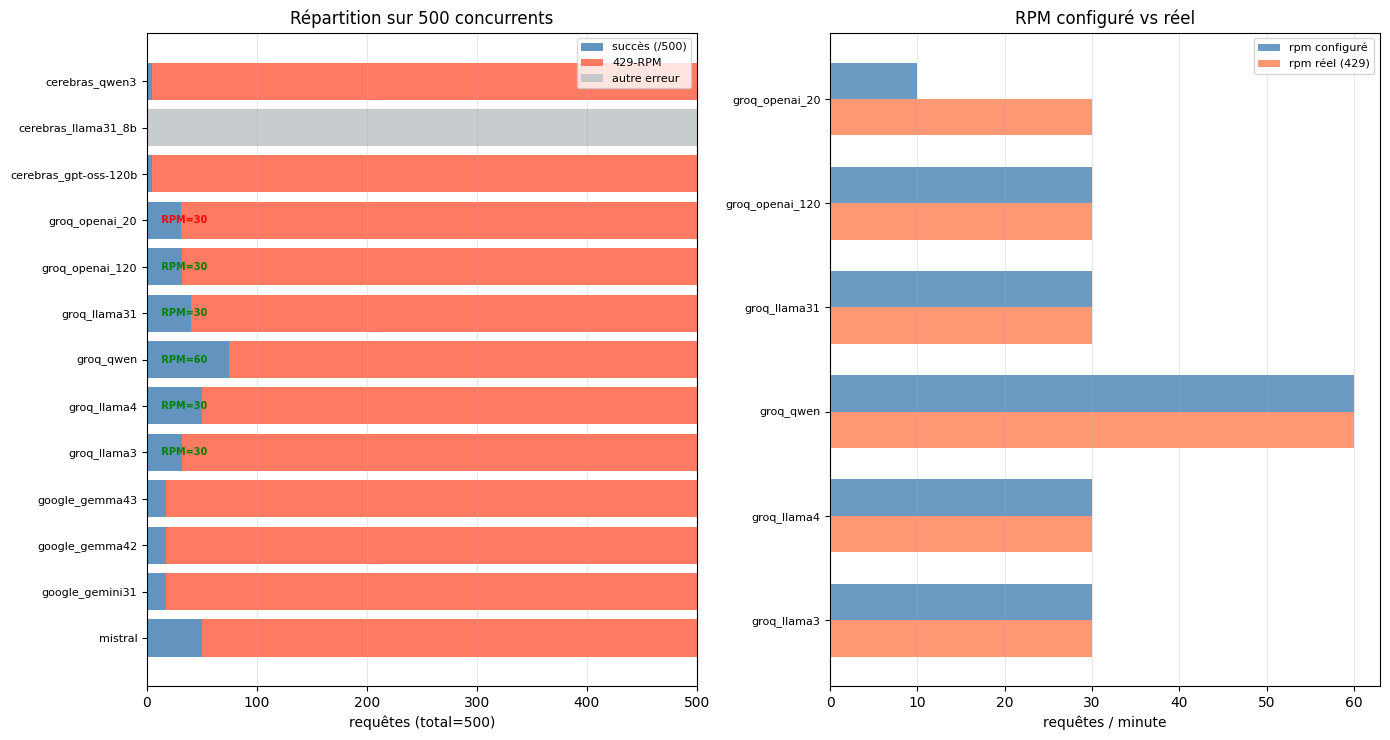

In [34]:
def _img_path(title, ext='png'):
    d = Path('../../experiments/current/images/benchmark')
    d.mkdir(parents=True, exist_ok=True)
    name = ''.join(c if c.isalnum() or c in '-_' else '_' for c in title)
    return str(d / f'{name}.{ext}')


tested = [n for n in rpm_results if rpm_results[n]['results']]
n = len(tested)
fig, axes = plt.subplots(1, 2, figsize=(14, max(3, n * 0.5 + 1)))

# ── Gauche : proportion succès/erreurs ───────────────────────────────────────
ax = axes[0]
labels, ok_vals, e429_vals, other_vals = [], [], [], []
for name in tested:
    res = rpm_results[name]['results']
    labels.append(name)
    ok_vals.append(sum(1 for r in res if r['ok']))
    e429_vals.append(sum(1 for r in res if r['status'] == 429))
    other_vals.append(sum(1 for r in res if not r['ok'] and r['status'] != 429))

y = range(len(labels))
ax.barh(y, ok_vals,    color='steelblue', label=f'succès (/{N_BURST})', alpha=0.85)
ax.barh(y, e429_vals,  left=ok_vals, color='tomato',    label='429-RPM', alpha=0.85)
ax.barh(y, other_vals, left=[a+b for a,b in zip(ok_vals, e429_vals)],
        color='#bdc3c7', label='autre erreur', alpha=0.85)

ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel(f'requêtes (total={N_BURST})')
ax.set_title(f'Répartition sur {N_BURST} concurrents')
ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)

# Annoter avec le RPM réel extrait
for i, name in enumerate(labels):
    burst = rpm_results[name]['results']
    body  = next((r['body'] for r in burst if not r['ok'] and r['body']), '')
    rpm   = _parse_rpm_limit(body or '')
    cfg_r = providers[name].get('rpm_limit')
    tag   = f" RPM={rpm}" if rpm else ''
    color = 'green' if (rpm and rpm == cfg_r) else ('red' if rpm else 'gray')
    ax.text(N_BURST * 0.02, i, tag, va='center', color=color, fontsize=7, fontweight='bold')

# ── Droite : RPM configuré vs réel ───────────────────────────────────────────
ax2 = axes[1]
df_plot = df_summary[df_summary['rpm_réel'].notna()].copy()

if df_plot.empty:
    ax2.text(0.5, 0.5, 'Aucun RPM réel extrait\n(pas de 429-RPM)', ha='center', va='center',
             transform=ax2.transAxes, fontsize=10, color='gray')
else:
    yp = range(len(df_plot))
    ax2.barh(yp, df_plot['rpm_config'], height=0.35, align='edge',
             label='rpm configuré', color='steelblue', alpha=0.8)
    ax2.barh([y - 0.35 for y in yp], df_plot['rpm_réel'], height=0.35, align='edge',
             label='rpm réel (429)', color='coral', alpha=0.8)
    ax2.set_yticks(list(yp)); ax2.set_yticklabels(df_plot.index, fontsize=8)
    ax2.set_xlabel('requêtes / minute')
    ax2.set_title('RPM configuré vs réel')
    ax2.legend(fontsize=8); ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(_img_path('rpm_burst_summary'), dpi=150)
plt.show()

## Détail des messages 429 / 413

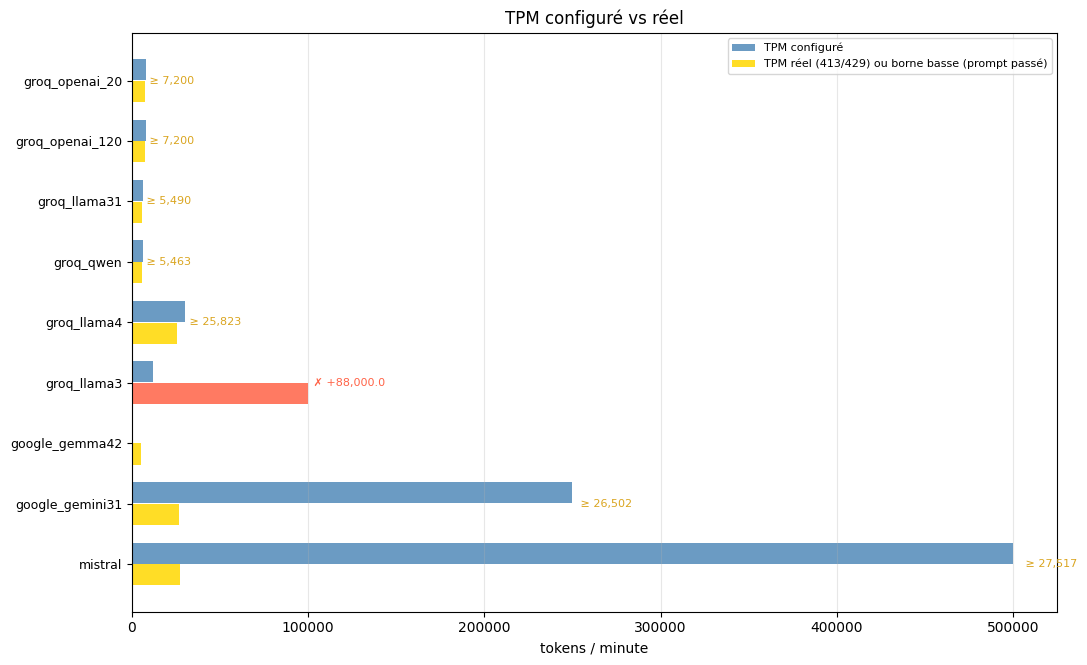

In [35]:

# ── TPM : configuré vs réel ────────────────────────────────────────────────────
tpm_plot_rows = []
for name, cfg in providers.items():
    if not cfg['api_key']:
        continue
    tpm_cfg = cfg.get('tpm_limit')
    tpm_res = tpm_results.get(name, {})
    tpm_body = tpm_res.get('body') or ''
    tpm_info = _parse_tpm_info(tpm_body)

    if tpm_info:
        tpm_actual = tpm_info['limit']
        kind = 'mesuré'
        match = (tpm_cfg == tpm_actual)
    elif tpm_res.get('ok'):
        tpm_actual = tpm_res.get('tokens_in', 0)   # borne basse connue
        kind = 'borne basse (prompt passé)'
        match = None   # on ne peut pas conclure
    else:
        continue   # pas de données TPM pour ce provider

    tpm_plot_rows.append({
        'provider': name,
        'tpm_config': tpm_cfg,
        'tpm_actual': tpm_actual,
        'kind': kind,
        'match': match,
    })

if not tpm_plot_rows:
    print('Aucune donnée TPM à afficher (aucun 413/429-TPM et aucune requête TPM réussie).')
else:
    df_tpm_plot = pd.DataFrame(tpm_plot_rows).set_index('provider')

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_tpm_plot) * 0.75)))
    y = range(len(df_tpm_plot))

    # Barres TPM configuré
    ax.barh(
        [i + 0.18 for i in y], df_tpm_plot['tpm_config'].fillna(0),
        height=0.35, color='steelblue', alpha=0.8, label='TPM configuré',
    )

    # Barres TPM réel / borne basse
    bar_colors = []
    for _, row in df_tpm_plot.iterrows():
        if row['match'] is True:
            bar_colors.append('mediumseagreen')
        elif row['match'] is False:
            bar_colors.append('tomato')
        else:
            bar_colors.append('gold')   # borne basse uniquement

    ax.barh(
        [i - 0.18 for i in y], df_tpm_plot['tpm_actual'].fillna(0),
        height=0.35, color=bar_colors, alpha=0.85,
        label='TPM réel (413/429) ou borne basse (prompt passé)',
    )

    ax.set_yticks(list(y))
    ax.set_yticklabels(df_tpm_plot.index, fontsize=9)
    ax.set_xlabel('tokens / minute')
    ax.set_title('TPM configuré vs réel')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

    # Annotations
    for i, (prov, row) in enumerate(df_tpm_plot.iterrows()):
        cfg_v   = row['tpm_config'] or 0
        actual_v = row['tpm_actual'] or 0
        x_max   = max(cfg_v, actual_v) * 1.01 + 100

        if row['match'] is True:
            ax.text(x_max, i, ' ✓', va='center', color='mediumseagreen', fontsize=10, fontweight='bold')
        elif row['match'] is False:
            delta = actual_v - cfg_v
            sign  = '+' if delta > 0 else ''
            ax.text(x_max, i, f' ✗ {sign}{delta:,}', va='center', color='tomato', fontsize=8)
        else:
            ax.text(x_max, i, f' ≥ {actual_v:,}', va='center', color='goldenrod', fontsize=8)

    plt.tight_layout()
    plt.savefig(_img_path('tpm_config_vs_real'), dpi=150)
    plt.show()


In [36]:
pd.set_option('display.max_colwidth', None)

# Messages d'erreur uniques du burst RPM
print('=== Messages d\'erreur uniques (burst RPM) ===')
seen = set()
rows = []
for name in tested:
    for r in rpm_results[name]['results']:
        if not r['ok'] and r['body']:
            key = (name, r['status'], r['body'][:150])
            if key not in seen:
                seen.add(key)
                rpm_lim = _parse_rpm_limit(r['body'])
                rows.append({'provider': name, 'http_status': r['status'],
                             'rpm_extrait': rpm_lim, 'message': r['body'][:200]})

if rows:
    display(pd.DataFrame(rows))
else:
    print('Aucune erreur dans le burst — rpm_limit trop conservatif ou N_BURST trop faible.')

# Messages du test TPM
print('\n=== Messages d\'erreur (test TPM long prompt) ===')
tpm_rows = []
for name, r in tpm_results.items():
    if not r.get('ok') and r.get('body'):
        info = _parse_tpm_info(r['body'])
        tpm_rows.append({'provider': name, 'http_status': r['status'],
                         'tpm_extrait': info, 'message': r['body'][:300]})
    elif r.get('ok'):
        tpm_rows.append({'provider': name, 'http_status': 200,
                         'tpm_extrait': None,
                         'message': f"OK — tokens_in={r['tokens_in']}, tokens_out={r['tokens_out']}"})

if tpm_rows:
    display(pd.DataFrame(tpm_rows))
else:
    print('Aucun résultat TPM.')

=== Messages d'erreur uniques (burst RPM) ===


,provider,http_status,rpm_extrait,message
0,mistral,429,NaN,"{""object"":""error"",""message"":""Rate limit exceeded"",""type"":""rate_limited"",""param"":null,""code"":""1300"",""raw_status_code"":429}"
1,google_gemini31,429,NaN,"{\n ""error"": {\n ""code"": 429,\n ""message"": ""You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-a"
2,google_gemma42,429,NaN,"{\n ""error"": {\n ""code"": 429,\n ""message"": ""You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-a"
3,google_gemma43,429,NaN,"{\n ""error"": {\n ""code"": 429,\n ""message"": ""You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-a"
4,groq_llama3,429,30.0,"{""error"":{""message"":""Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on requests per minute (RPM): Limit 30, Used 30, R"
5,groq_llama4,429,30.0,"{""error"":{""message"":""Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on requests per minute (RPM): Li"
6,groq_qwen,429,60.0,"{""error"":{""message"":""Rate limit reached for model `qwen/qwen3-32b` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on requests per minute (RPM): Limit 60, Used 60, Requested"
7,groq_llama31,429,30.0,"{""error"":{""message"":""Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on requests per minute (RPM): Limit 30, Used 30, Requ"
8,groq_openai_120,429,30.0,"{""error"":{""message"":""Rate limit reached for model `openai/gpt-oss-120b` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on requests per minute (RPM): Limit 30, Used 30, Reque"
9,groq_openai_20,429,30.0,"{""error"":{""message"":""Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on requests per minute (RPM): Limit 30, Used 30, Reques"



=== Messages d'erreur (test TPM long prompt) ===


,provider,http_status,tpm_extrait,message
0,mistral,200,None,"OK — tokens_in=27517, tokens_out=10"
1,google_gemini31,200,None,"OK — tokens_in=26502, tokens_out=6"
2,google_gemma42,200,None,"OK — tokens_in=5302, tokens_out=0"
3,google_gemma43,429,None,"{\n ""error"": {\n ""code"": 429,\n ""message"": ""You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota ex"
4,groq_llama3,429,"{'quota_type': 'TPD', 'limit': 100000, 'used': 90697, 'requested': 10568}","{""error"":{""message"":""Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kd3cw53ffr7b7r5mfmjt1nry` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 90697, Requested 10568. Please try again in 18m12.96s. Need more tokens? Upgrade to Dev Tier today at http"
5,groq_llama4,200,None,"OK — tokens_in=25823, tokens_out=10"
6,groq_qwen,200,None,"OK — tokens_in=5463, tokens_out=10"
7,groq_llama31,200,None,"OK — tokens_in=5490, tokens_out=10"
8,groq_openai_120,200,None,"OK — tokens_in=7200, tokens_out=10"
9,groq_openai_20,200,None,"OK — tokens_in=7200, tokens_out=10"


## Recommandations — providers.yaml

In [37]:

recs = []   # liste de dicts {provider, champ, valeur_actuelle, valeur_recommandée, raison, priorité}

for name, cfg in providers.items():
    if not cfg['api_key']:
        continue

    rpm_cfg = cfg.get('rpm_limit')
    tpm_cfg = cfg.get('tpm_limit')
    tpd_cfg = cfg.get('tpd_limit')

    # ── RPM ──────────────────────────────────────────────────────────────────
    burst    = rpm_results.get(name, {}).get('results', [])
    body_429 = next((r['body'] for r in burst if not r['ok'] and r['body']), '') or ''
    rpm_real = _parse_rpm_limit(body_429)

    if rpm_real is not None and rpm_real != rpm_cfg:
        recs.append({
            'provider':    name,
            'champ':       'rpm_limit',
            'actuel':      rpm_cfg,
            'recommandé':  rpm_real,
            'priorité':    '🔴 haute' if abs(rpm_real - (rpm_cfg or 0)) / max(rpm_cfg or 1, 1) > 0.2 else '🟡 moyenne',
            'raison':      f'Limite réelle extraite du message 429-RPM : {rpm_real}',
        })

    # ── TPM ──────────────────────────────────────────────────────────────────
    tpm_res  = tpm_results.get(name, {})
    tpm_body = tpm_res.get('body') or ''
    tpm_info = _parse_tpm_info(tpm_body)

    if tpm_info:
        tpm_real      = tpm_info['limit']
        qt            = tpm_info['quota_type']
        target_field  = 'tpm_limit' if qt == 'TPM' else 'tpd_limit'
        current_val   = tpm_cfg if qt == 'TPM' else tpd_cfg

        if tpm_real != current_val:
            recs.append({
                'provider':    name,
                'champ':       target_field,
                'actuel':      current_val,
                'recommandé':  tpm_real,
                'priorité':    '🔴 haute' if current_val and abs(tpm_real - current_val) / max(current_val, 1) > 0.2 else '🟡 moyenne',
                'raison':      f'Limite réelle extraite du message 413/{qt} : {tpm_real:,}',
            })
        else:
            recs.append({
                'provider':    name,
                'champ':       target_field,
                'actuel':      current_val,
                'recommandé':  current_val,
                'priorité':    '🟢 ok',
                'raison':      f'Confirmé par test ({qt}={tpm_real:,})',
            })

    elif tpm_res.get('ok'):
        # Prompt passé : borne basse, on ne peut pas confirmer la valeur exacte
        tokens_used = tpm_res.get('tokens_in', 0)
        if tpm_cfg and tpm_cfg < tokens_used:
            recs.append({
                'provider':    name,
                'champ':       'tpm_limit',
                'actuel':      tpm_cfg,
                'recommandé':  f'≥ {tokens_used:,} (TBC)',
                'priorité':    '🔴 haute',
                'raison':      f'tpm_config ({tpm_cfg:,}) < tokens utilisés ({tokens_used:,}) — config incohérente',
            })
        elif tpm_cfg is None:
            recs.append({
                'provider':    name,
                'champ':       'tpm_limit',
                'actuel':      None,
                'recommandé':  f'≥ {tokens_used:,} (TBC)',
                'priorité':    '🟡 moyenne',
                'raison':      f'Prompt de {tokens_used:,} tokens passé mais tpm_limit non renseigné. '
                               f'Augmenter MAX_PROMPT_TOKENS pour tester plus haut.',
            })
        else:
            recs.append({
                'provider':    name,
                'champ':       'tpm_limit',
                'actuel':      tpm_cfg,
                'recommandé':  tpm_cfg,
                'priorité':    '⚪ non confirmé',
                'raison':      f'Prompt plafonné à {tokens_used:,} tokens (< tpm_config={tpm_cfg:,}). '
                               f'Augmenter MAX_PROMPT_TOKENS pour confirmer.',
            })
    else:
        recs.append({
            'provider':   name,
            'champ':      'tpm_limit',
            'actuel':     tpm_cfg,
            'recommandé': '?',
            'priorité':   '⚪ échec test',
            'raison':     f'Erreur HTTP {tpm_res.get("status")} sans info quota parsable',
        })

# ── Affichage ─────────────────────────────────────────────────────────────────
df_recs = (
    pd.DataFrame(recs)
    .sort_values(['priorité', 'provider'])
    .reset_index(drop=True)
)
pd.set_option('display.max_colwidth', 80)
display(df_recs[['priorité', 'provider', 'champ', 'actuel', 'recommandé', 'raison']])

# ── Diff YAML ─────────────────────────────────────────────────────────────────
changes = [r for r in recs if str(r['actuel']) != str(r['recommandé']) and r['recommandé'] != '?']
if not changes:
    print('\n✓ Aucun changement nécessaire dans providers.yaml.')
else:
    print(f'\n{"─"*60}')
    print('Diff suggéré pour providers.yaml')
    print(f'{"─"*60}')
    by_provider = {}
    for r in changes:
        by_provider.setdefault(r['provider'], []).append(r)

    for prov, items in by_provider.items():
        print(f'\n  {prov}:')
        for item in items:
            old = item['actuel']
            new = item['recommandé']
            field = item['champ']
            if item['priorité'].startswith('🟢'):
                continue
            print(f'    # {item["raison"]}')
            print(f'-   {field}: {old}')
            print(f'+   {field}: {new}')


,priorité,provider,champ,actuel,recommandé,raison
0,⚪ non confirmé,google_gemini31,tpm_limit,250000.0,250000,"Prompt plafonné à 26,502 tokens (< tpm_config=250,000). Augmenter MAX_PROMPT..."
1,⚪ non confirmé,groq_llama31,tpm_limit,6000.0,6000,"Prompt plafonné à 5,490 tokens (< tpm_config=6,000). Augmenter MAX_PROMPT_TO..."
2,⚪ non confirmé,groq_llama4,tpm_limit,30000.0,30000,"Prompt plafonné à 25,823 tokens (< tpm_config=30,000). Augmenter MAX_PROMPT_..."
3,⚪ non confirmé,groq_openai_120,tpm_limit,8000.0,8000,"Prompt plafonné à 7,200 tokens (< tpm_config=8,000). Augmenter MAX_PROMPT_TO..."
4,⚪ non confirmé,groq_openai_20,tpm_limit,8000.0,8000,"Prompt plafonné à 7,200 tokens (< tpm_config=8,000). Augmenter MAX_PROMPT_TO..."
5,⚪ non confirmé,groq_qwen,tpm_limit,6000.0,6000,"Prompt plafonné à 5,463 tokens (< tpm_config=6,000). Augmenter MAX_PROMPT_TO..."
6,⚪ non confirmé,mistral,tpm_limit,500000.0,500000,"Prompt plafonné à 27,517 tokens (< tpm_config=500,000). Augmenter MAX_PROMPT..."
7,⚪ échec test,cerebras_gpt-oss-120b,tpm_limit,30000.0,?,Erreur HTTP 429 sans info quota parsable
8,⚪ échec test,cerebras_llama31_8b,tpm_limit,30000.0,?,Erreur HTTP 404 sans info quota parsable
9,⚪ échec test,cerebras_qwen3,tpm_limit,30000.0,?,Erreur HTTP 429 sans info quota parsable



────────────────────────────────────────────────────────────
Diff suggéré pour providers.yaml
────────────────────────────────────────────────────────────

  google_gemma42:
    # Prompt de 5,302 tokens passé mais tpm_limit non renseigné. Augmenter MAX_PROMPT_TOKENS pour tester plus haut.
-   tpm_limit: None
+   tpm_limit: ≥ 5,302 (TBC)

  groq_openai_20:
    # Limite réelle extraite du message 429-RPM : 30
-   rpm_limit: 10
+   rpm_limit: 30
